# Text Classification with RNN / LSTM
## News Category Dataset — Kaggle Notebook
**Dataset:** `news_category.csv` — predict article category from headline  
**Models:** Simple RNN · LSTM · LSTM + GloVe (Word2Vec)


## 1. Install Dependencies & Imports

In [18]:
!pip install gensim --quiet
!pip install contractions --quiet
!pip install wordcloud --quiet


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, unicodedata, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
nltk.download('punkt',     quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)


TensorFlow: 2.19.0
NumPy: 2.0.2


## 2. Load the Dataset

In [20]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/silviamaharjan/news-category-dataset/News Category/news_category.csv"

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(df.head())

Shape: (11025, 2)
                                            headline        category
0  How A New Documentary Captures The Complexity ...  CULTURE & ARTS
1  Twitch Bans Gambling Sites After Streamer Scam...            TECH
2  'Reboot' Is A Clever And Not Too Navel-Gazey L...  CULTURE & ARTS
3  Maury Wills, Base-Stealing Shortstop For Dodge...          SPORTS
4  Las Vegas Aces Win First WNBA Title, Chelsea G...          SPORTS


## 3. Dataset Noise Identification & Handling

Before any modelling, we systematically audit the raw data for **seven categories of noise**
identified in this dataset, then apply targeted fixes.

| # | Noise Type | Found | Action |
|---|---|---|---|
| 1 | Duplicate headlines (same category) | 78 | Drop |
| 2 | Duplicate headlines (different category — label noise) | 2 | Drop both copies |
| 3 | Non-ASCII / Unicode noise (curly quotes, em-dashes, accented chars, invisible spaces) | 311 rows | Normalise / strip |
| 4 | Multiple consecutive spaces | 43 | Collapse to single space |
| 5 | Headlines with ≤ 1 informative token after cleaning | 8 | Drop |
| 6 | Very short headlines (≤ 2 words) | 37 | Flag (kept if ≥ 1 token survives cleaning) |
| 7 | Class imbalance (SPORTS 5077 vs EDUCATION 1014) | — | Noted; handled via stratified split |


### 3.1 Audit — Identify All Noise

In [21]:
print("-" * 60)
print("            NEWS CATEGORY DATASET NOISE REPORT")
print("-" * 60)

# 1 & 2. Duplicates
seen = {}
same_cat_dupes, diff_cat_dupes = [], []
for idx, (h, c) in enumerate(zip(df['headline'], df['category'])):
    if h in seen:
        if seen[h]['cat'] == c:
            same_cat_dupes.append(idx)          # exact duplicate
        else:
            diff_cat_dupes.append(idx)          # label-conflicting duplicate
            diff_cat_dupes.append(seen[h]['idx'])
    else:
        seen[h] = {'cat': c, 'idx': idx}

print(f"\n1. Exact duplicates (same category)   : {len(same_cat_dupes)}")
print(f"2. Label-conflicting duplicates        : {len(set(diff_cat_dupes))} rows")
print("   Examples:")
for idx in list(set(diff_cat_dupes))[:4]:
    print(f"     [{df.loc[idx,'category']}] \"{df.loc[idx,'headline']}\"")

# 3. Non-ASCII characters
non_ascii_mask = df['headline'].apply(lambda h: bool(re.search(r'[^\x00-\x7F]', str(h))))
print(f"\n3. Headlines containing non-ASCII chars: {non_ascii_mask.sum()}")
non_ascii_chars = Counter()
for h in df.loc[non_ascii_mask, 'headline']:
    for ch in str(h):
        if ord(ch) > 127:
            non_ascii_chars[unicodedata.name(ch, 'UNKNOWN')] += 1
print("   Top Unicode noise characters:")
for name, cnt in non_ascii_chars.most_common(8):
    print(f"     {cnt:3d}x  {name}")

# 4. Multiple consecutive spaces
multi_space_mask = df['headline'].str.contains(r'  ', regex=False)
print(f"\n4. Headlines with multiple consecutive spaces: {multi_space_mask.sum()}")
print("   Example:", df.loc[multi_space_mask, 'headline'].iloc[0])

# 5. Short headlines
df['_word_count'] = df['headline'].apply(lambda h: len(str(h).split()))
short_mask = df['_word_count'] <= 2
print(f"\n5. Headlines with ≤ 2 words: {short_mask.sum()}")
print("   Examples:", df.loc[short_mask, 'headline'].tolist()[:5])

# 6. Class distribution
print("\n6. Class distribution (imbalance check):")
for cat, cnt in df['category'].value_counts().items():
    bar = ' ' * (cnt // 100)
    print(f"   {cat:<18}: {cnt:5d}  {bar}")

print("\n" + "=" * 60)


------------------------------------------------------------
            NEWS CATEGORY DATASET NOISE REPORT
------------------------------------------------------------

1. Exact duplicates (same category)   : 78
2. Label-conflicting duplicates        : 4 rows
   Examples:
     [CULTURE & ARTS] "Learning From the Masters"
     [SPORTS] "Learning From the Masters"
     [TECH] "Can You Hear Me Now?"
     [CULTURE & ARTS] "Can You Hear Me Now?"

3. Headlines containing non-ASCII chars: 311
   Top Unicode noise characters:
     284x  RIGHT SINGLE QUOTATION MARK
      60x  LEFT SINGLE QUOTATION MARK
      14x  LATIN SMALL LETTER E WITH ACUTE
      12x  EM DASH
      10x  NO-BREAK SPACE
       6x  EN DASH
       4x  HAIR SPACE
       2x  LATIN SMALL LETTER A WITH DIAERESIS

4. Headlines with multiple consecutive spaces: 43
   Example: Adults Must Teach Kids To Use,  Not Be Used By, Social Media

5. Headlines with ≤ 2 words: 37
   Examples: ['Teaching Trump', 'Dear Teachers', 'Betterocracy', 

### 3.2 Fix — Apply All Noise Corrections

In [22]:
df_clean = df.copy()
original_size = len(df_clean)

# Fix 1 & 2: Removing all duplicate headlines (both exact and label-conflicting)
df_clean = df_clean.drop_duplicates(subset='headline', keep=False)   # drop conflicting first
df_clean = df_clean.drop_duplicates(subset='headline', keep='first') # then exact dupes
print(f"Rows after removing duplicates   : {len(df_clean)}  (removed {original_size - len(df_clean)})")

# Fix 3a: Normalising curly/smart quotes → straight ASCII
def normalise_unicode(text: str) -> str:
    # Curly single quotes → apostrophe
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    # Curly double quotes → straight
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    # Em-dash / en-dash / horizontal bar → hyphen-space
    text = text.replace('\u2014', ' - ').replace('\u2013', ' - ').replace('\u2015', ' - ')
    # Ellipsis → three dots
    text = text.replace('\u2026', '...')
    # No-break space, hair space, zero-width no-break space → regular space
    text = text.replace('\u00a0', ' ').replace('\u200a', ' ').replace('\ufeff', '')
    # Accented Latin letters → closest ASCII via NFKD decomposition
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    return text

df_clean['headline'] = df_clean['headline'].apply(normalise_unicode)
non_ascii_after = df_clean['headline'].apply(lambda h: bool(re.search(r'[^\x00-\x7F]', h))).sum()
print(f"Non-ASCII headlines after normalisation: {non_ascii_after}")

# Fix 4: Collapsing multiple spaces to one
df_clean['headline'] = df_clean['headline'].str.replace(r'\s+', ' ', regex=True).str.strip()
multi_after = df_clean['headline'].str.contains('  ', regex=False).sum()
print(f"Multi-space headlines after fix  : {multi_after}")

# Fix 5: Droping rows that will have < 1 meaningful token after cleaning
_stop = set(stopwords.words('english'))
def rough_token_count(text):
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    return sum(1 for t in text.split() if t not in _stop and len(t) > 1)

df_clean['_rtc'] = df_clean['headline'].apply(rough_token_count)
too_short_mask = df_clean['_rtc'] < 1
print(f"Rows with < 1 informative token  : {too_short_mask.sum()}  → dropping")
df_clean = df_clean[~too_short_mask]

# Cleanup helper columns
df_clean.drop(columns=['_word_count', '_rtc'], inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print(f"\nFinal dataset size: {len(df_clean)}  (removed {original_size - len(df_clean)} noisy rows total)")
print("\nClass distribution after cleaning:")
print(df_clean['category'].value_counts())


Rows after removing duplicates   : 10918  (removed 107)
Non-ASCII headlines after normalisation: 0
Multi-space headlines after fix  : 0
Rows with < 1 informative token  : 0  → dropping

Final dataset size: 10918  (removed 107 noisy rows total)

Class distribution after cleaning:
category
SPORTS            5074
TECH              2041
MONEY             1752
CULTURE & ARTS    1037
EDUCATION         1014
Name: count, dtype: int64


### 3.3 Noise Summary Visualisation

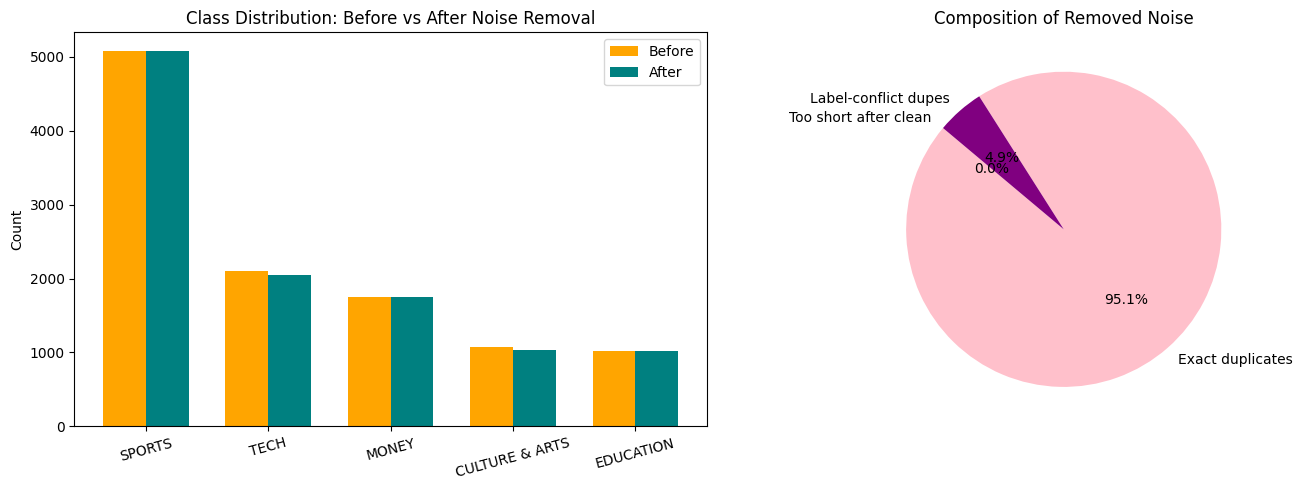

Total noisy rows removed: 107


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before vs after class dist
cats = df['category'].value_counts().index.tolist()
before_counts = [df['category'].value_counts()[c] for c in cats]
after_counts  = [df_clean['category'].value_counts().get(c, 0) for c in cats]

x = np.arange(len(cats))
w = 0.35
axes[0].bar(x - w/2, before_counts, w, label='Before', color='orange')
axes[0].bar(x + w/2, after_counts,  w, label='After',  color='teal')
axes[0].set_xticks(x); axes[0].set_xticklabels(cats, rotation=15)
axes[0].set_title('Class Distribution: Before vs After Noise Removal')
axes[0].set_ylabel('Count'); axes[0].legend()

# Noise breakdown pie
noise_labels = ['Exact duplicates', 'Label-conflict dupes', 'Too short after clean']
noise_vals   = [78, len(set(diff_cat_dupes)), too_short_mask.sum()]
axes[1].pie(noise_vals, labels=noise_labels, autopct='%1.1f%%',
            colors=['pink','purple','orange'], startangle=140)
axes[1].set_title('Composition of Removed Noise')

plt.tight_layout()
plt.savefig('noise_analysis.png', dpi=100)
plt.show()
print(f"Total noisy rows removed: {original_size - len(df_clean)}")


## 4. Exploratory Data Analysis

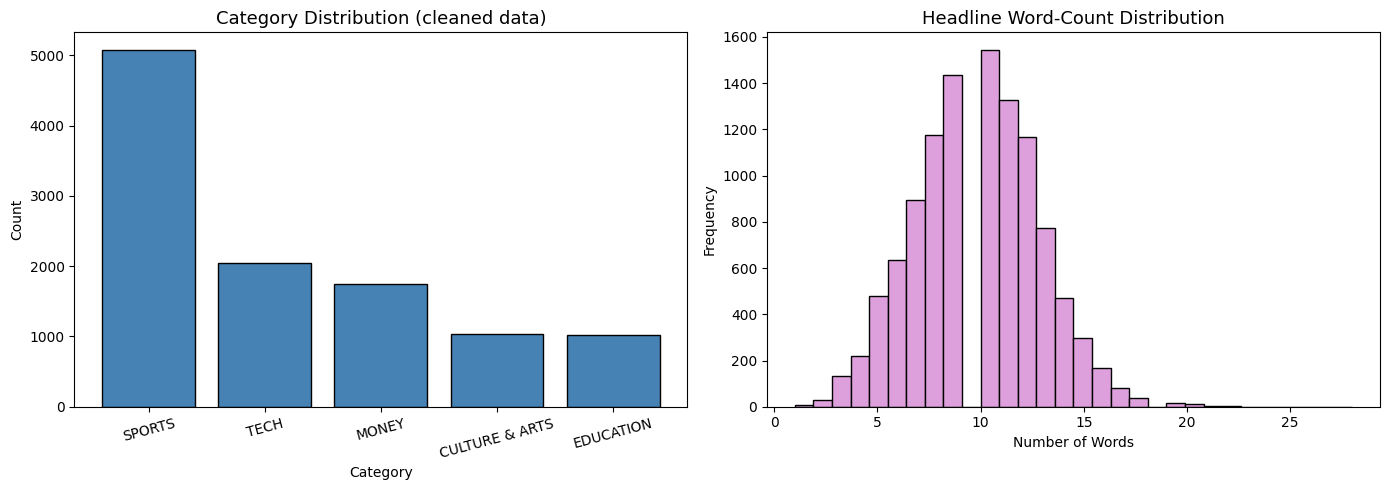

Headline length stats (cleaned):
count    10918.000000
mean         9.792361
std          2.994672
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         28.000000
Name: headline_len, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df_clean['category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Category Distribution (cleaned data)', fontsize=13)
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

df_clean['headline_len'] = df_clean['headline'].apply(lambda x: len(str(x).split()))
axes[1].hist(df_clean['headline_len'], bins=30, color='plum', edgecolor='black')
axes[1].set_title('Headline Word-Count Distribution', fontsize=13)
axes[1].set_xlabel('Number of Words'); axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=100)
plt.show()
print("Headline length stats (cleaned):")
print(df_clean['headline_len'].describe())


## 5. Text Pre-processing, Tokenisation & Sequence Padding
### 5.1 Text Cleaning Pipeline


In [25]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Full cleaning pipeline:
    1. Lowercasing text
    2. Expanding contractions
    3. Removing URLs
    4. Removing mentions and hashtags
    5. Removing numbers
    6. Removing punctuation / special characters
    7. Removing stopwords
    8. Lemmatizing words
    """

    # Lowercasing text
    text = text.lower()

    # Expanding contractions
    text = contractions.fix(text)

    # Removing URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Removing mentions and hashtags
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)

    # Removing numbers
    text = re.sub(r'\d+', ' ', text)

    # Removing punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenizing text and removing stopwords
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]

    # Lemmatizing words
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]

    return ' '.join(tokens)

df_clean['clean_headline'] = df_clean['headline'].astype(str).apply(clean_text)

print("Sample cleaned headlines:")
for orig, cleaned in zip(df_clean['headline'][:5], df_clean['clean_headline'][:5]):
    print(f"ORIGINAL  : {orig}")
    print(f"CLEANED   : {cleaned}\n")

Sample cleaned headlines:
ORIGINAL  : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
CLEANED   : new documentary capture complexity child immigrants

ORIGINAL  : Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
CLEANED   : twitch ban gamble sit streamer scam folks

ORIGINAL  : 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
CLEANED   : reboot clever navel gazey look inside tv reboot

ORIGINAL  : Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89
CLEANED   : maury will base steal shortstop dodgers die

ORIGINAL  : Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
CLEANED   : las vegas ace win first wnba title chelsea gray name mvp



### 5.2 Word Cloud & Top Frequent Terms

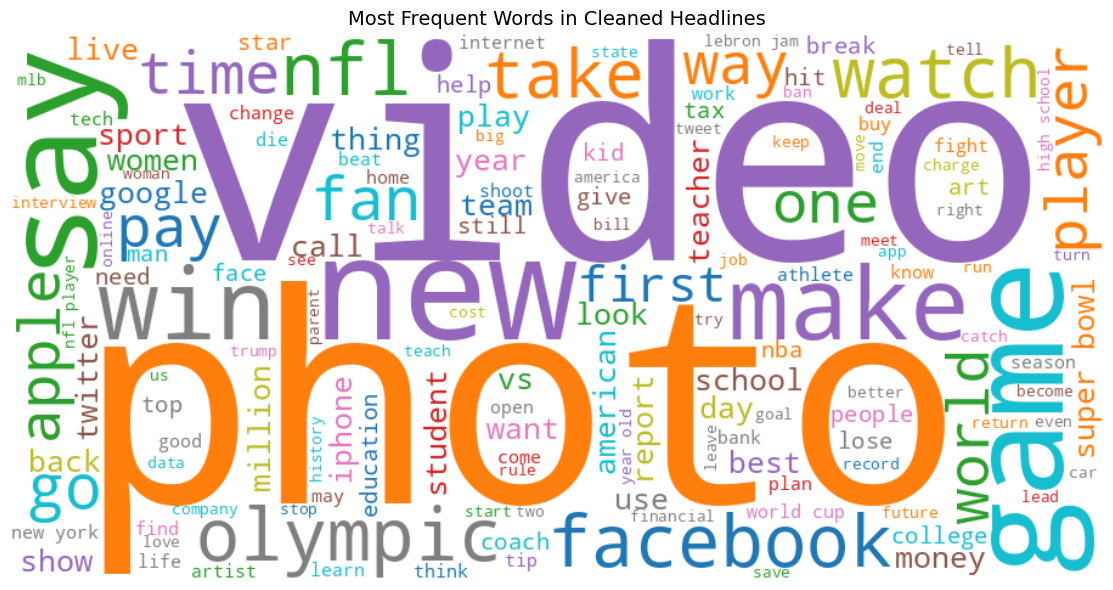

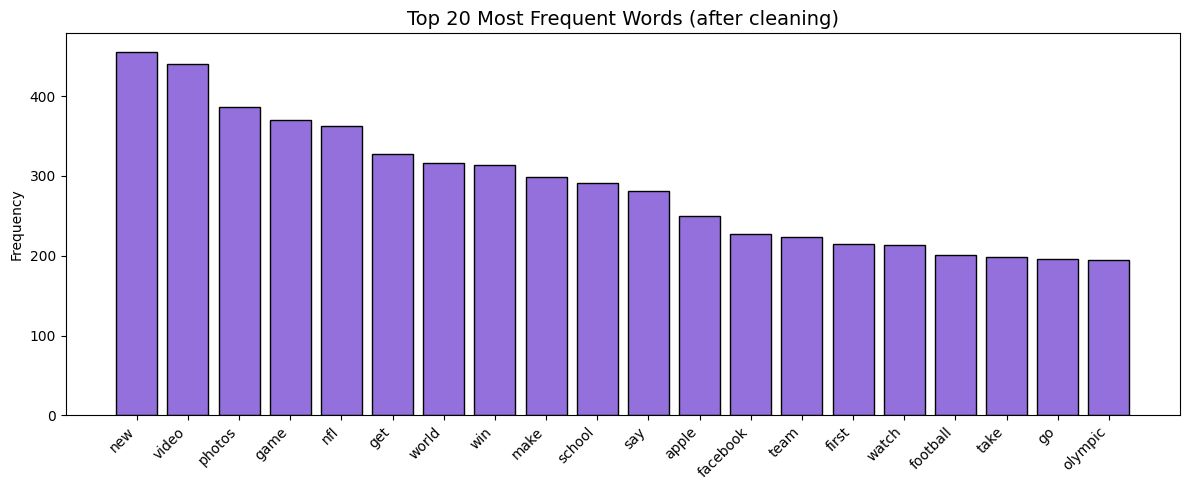

In [26]:
all_text = ' '.join(df_clean['clean_headline'].tolist())

wc = WordCloud(width=900, height=450, background_color='white',
               max_words=150, colormap='tab10').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Cleaned Headlines', fontsize=14)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=100)
plt.show()

word_freq = Counter(all_text.split())
top20 = word_freq.most_common(20)
words, freqs = zip(*top20)
plt.figure(figsize=(12, 5))
plt.bar(words, freqs, color='mediumpurple', edgecolor='black')
plt.title('Top 20 Most Frequent Words (after cleaning)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('top20_words.png', dpi=100)
plt.show()


### 5.3 Label Encoding

In [27]:
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['category'])
NUM_CLASSES = len(le.classes_)
print("Classes:", le.classes_)
print("Number of classes:", NUM_CLASSES)


Classes: ['CULTURE & ARTS' 'EDUCATION' 'MONEY' 'SPORTS' 'TECH']
Number of classes: 5


### 5.4 Train / Test Split (80 / 20) — Stratified

In [28]:
X = df_clean['clean_headline'].values
y = df_clean['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size : {len(X_train)}")

print("\nClass distribution in train set:")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {le.classes_[cls]:<18}: {cnt}")
    
print("-"*50)

print(f"Test size  : {len(X_test)}")
print("\nClass distribution in test set:")
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f"  {le.classes_[cls]:<18}: {cnt}")

Train size : 8734

Class distribution in train set:
  CULTURE & ARTS    : 830
  EDUCATION         : 811
  MONEY             : 1401
  SPORTS            : 4059
  TECH              : 1633
--------------------------------------------------
Test size  : 2184

Class distribution in test set:
  CULTURE & ARTS    : 207
  EDUCATION         : 203
  MONEY             : 351
  SPORTS            : 1015
  TECH              : 408


### 5.5 Keras Tokenisation & Percentile-Based Padding

In [29]:
VOCAB_SIZE = 10_000
OOV_TOKEN  = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)          # fit only on training data — no leakage

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding (avoids excessively long sequences from outliers)
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"95th-percentile sequence length (MAX_LEN) = {MAX_LEN}")
print(f"Max raw length = {max(lengths)},  Mean = {np.mean(lengths):.1f}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad  shape:", X_test_pad.shape)

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)


95th-percentile sequence length (MAX_LEN) = 11
Max raw length = 19,  Mean = 6.9
X_train_pad shape: (8734, 11)
X_test_pad  shape: (2184, 11)


## 6. Model Building

### 6.1 Model 1 — Simple RNN with Trainable Embedding

In [30]:
EMBED_DIM = 64

def build_rnn(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        SimpleRNN(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ], name='SimpleRNN_Model')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model1 = build_rnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model1.build(input_shape=(None, MAX_LEN))
model1.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,285 (2.57 MB)

 Trainable params: 673,285 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

### 6.2 Model 2 — LSTM with Trainable Embedding

In [31]:
def build_lstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ], name='LSTM_Model')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model2 = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model2.build(input_shape=(None, MAX_LEN))
model2.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,397 (2.85 MB)

 Trainable params: 747,397 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Model 3 — LSTM with Pre-trained GloVe Embeddings

In [32]:
import gensim.downloader as api

print("Downloading GloVe-Wiki-Gigaword-50 (one-time download ~66 MB)…")
embedding_model = api.load('glove-wiki-gigaword-50')
GLOVE_DIM = 50
print("Done.")

[==================================================] 100.0% 66.0/66.0MB downloaded
Done.


In [33]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found = 0
for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f"Words covered by GloVe: {found}/{min(len(word_index), VOCAB_SIZE)} ({coverage:.1f}%)")


Words covered by GloVe: 9547/10000 (95.5%)


In [45]:
def build_lstm_glove(vocab_size, glove_dim, embedding_matrix, max_len, num_classes):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=glove_dim,
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False,
        ),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ], name='LSTM_GloVe_Model')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model3 = build_lstm_glove(VOCAB_SIZE, GLOVE_DIM, embedding_matrix, MAX_LEN, NUM_CLASSES)
model3.build(input_shape=(None, MAX_LEN))
model3.summary()


Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 600,229 (2.29 MB)

 Trainable params: 100,229 (391.52 KB)

 Non-trainable params: 500,000 (1.91 MB)

## 7. Model Training

In [46]:
EPOCHS = 22
BATCH  = 64

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
]


### 7.1 Train Model 1 (Simple RNN)

In [47]:
history1 = model1.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.10,
    callbacks=callbacks, verbose=1,
)


Epoch 1/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9472 - loss: 0.1812 - val_accuracy: 0.7883 - val_loss: 0.7197 - learning_rate: 5.0000e-04
Epoch 2/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9742 - loss: 0.0945 - val_accuracy: 0.7929 - val_loss: 0.8243 - learning_rate: 5.0000e-04
Epoch 3/22
119/123 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9898 - loss: 0.0425
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9897 - loss: 0.0426 - val_accuracy: 0.7815 - val_loss: 0.9777 - learning_rate: 5.0000e-04
Epoch 4/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9951 - loss: 0.0216 - val_accuracy: 0.7883 - val_loss: 1.0541 - learning_rate: 2.5000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


### 7.2 Train Model 2 (LSTM)

In [48]:
history2 = model2.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.10,
    callbacks=callbacks, verbose=1,
)


Epoch 1/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9551 - loss: 0.1564 - val_accuracy: 0.8192 - val_loss: 0.6493 - learning_rate: 5.0000e-04
Epoch 2/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9763 - loss: 0.0865 - val_accuracy: 0.7872 - val_loss: 0.7851 - learning_rate: 5.0000e-04
Epoch 3/22
121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9873 - loss: 0.0519
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9873 - loss: 0.0520 - val_accuracy: 0.8078 - val_loss: 0.8862 - learning_rate: 5.0000e-04
Epoch 4/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9919 - loss: 0.0305 - val_accuracy: 0.7986 - val_loss: 0.9408 - learning_rate: 2.5000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


### 7.3 Train Model 3 (LSTM + GloVe)

In [49]:
history3 = model3.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.10,
    callbacks=callbacks, verbose=1,
)


Epoch 1/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5864 - loss: 1.0498 - val_accuracy: 0.8089 - val_loss: 0.5479 - learning_rate: 0.0010
Epoch 2/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8261 - loss: 0.5214 - val_accuracy: 0.8272 - val_loss: 0.5005 - learning_rate: 0.0010
Epoch 3/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8421 - loss: 0.4800 - val_accuracy: 0.8364 - val_loss: 0.4688 - learning_rate: 0.0010
Epoch 4/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8590 - loss: 0.4326 - val_accuracy: 0.8535 - val_loss: 0.4428 - learning_rate: 0.0010
Epoch 5/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8711 - loss: 0.4033 - val_accuracy: 0.8444 - val_loss: 0.4396 - learning_rate: 0.0010
Epoch 6/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8808 - loss: 0.3585 - val_accuracy: 0.8432 - val_loss: 0.4284 - learning_rate: 0.0010
Epoch 7/22
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8857 - loss: 0.

## 8. Training Visualisations

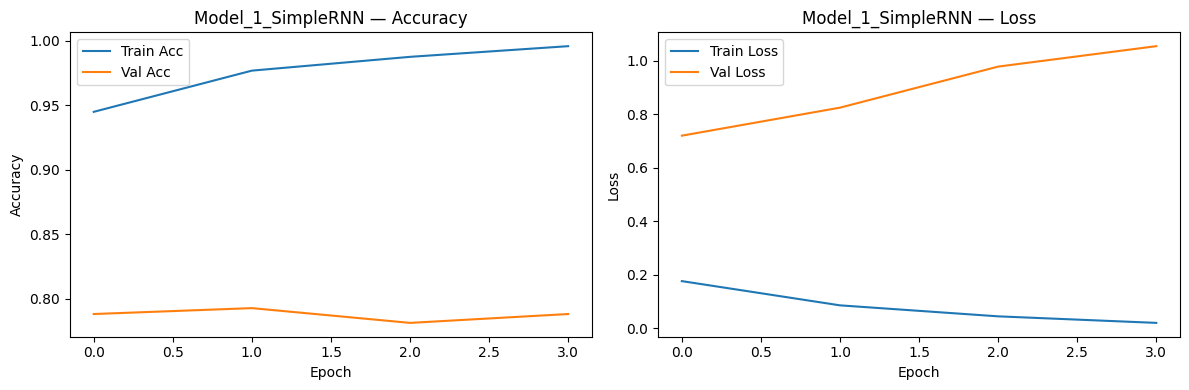

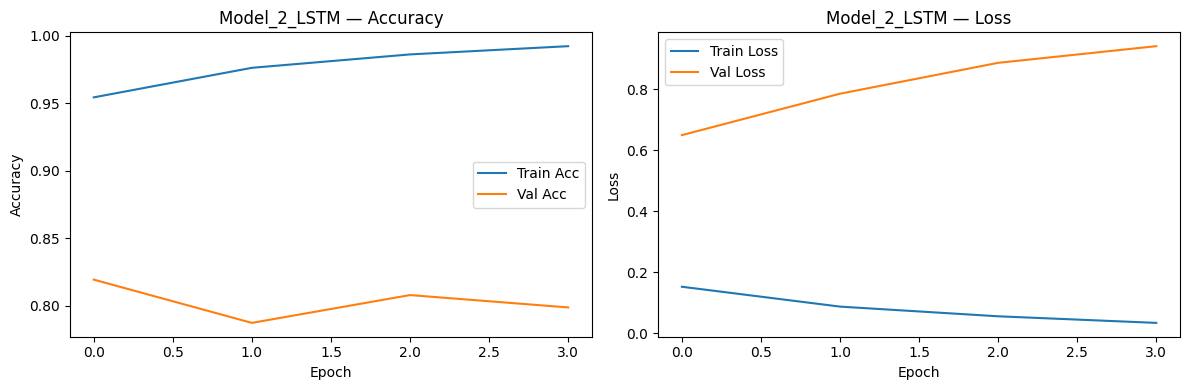

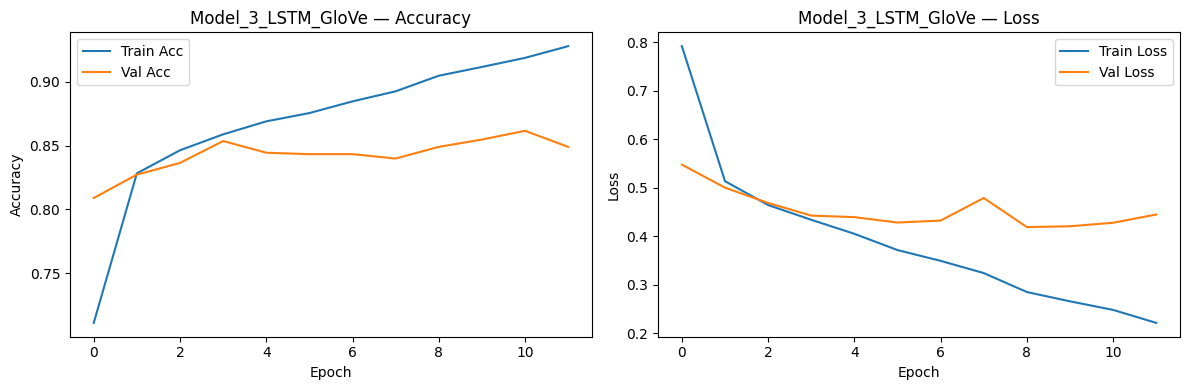

In [50]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()

    ax2.plot(history.history['loss'],     label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()

    plt.tight_layout()
    plt.savefig(title.replace(' ', '_') + '.png', dpi=100)
    plt.show()

plot_history(history1, 'Model_1_SimpleRNN')
plot_history(history2, 'Model_2_LSTM')
plot_history(history3, 'Model_3_LSTM_GloVe')


### 8.1 Comparative Accuracy Chart

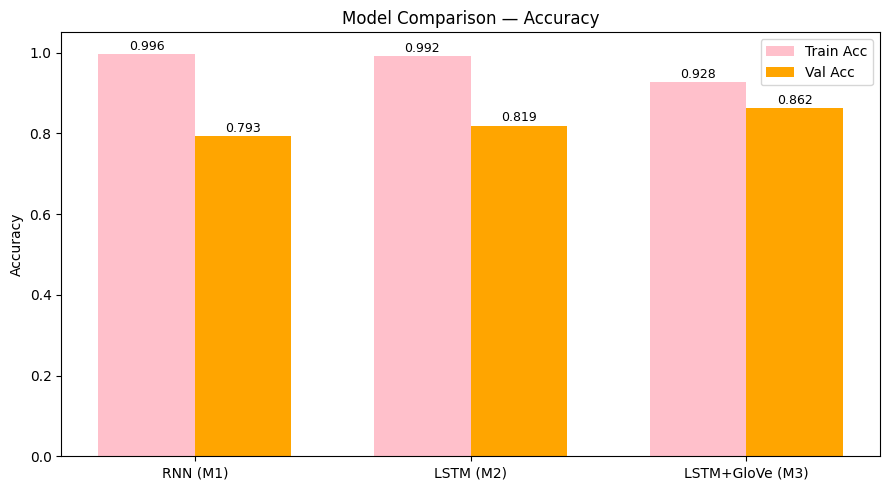

In [51]:
model_names = ['RNN (M1)', 'LSTM (M2)', 'LSTM+GloVe (M3)']
train_accs  = [max(h.history['accuracy'])     for h in [history1, history2, history3]]
val_accs    = [max(h.history['val_accuracy']) for h in [history1, history2, history3]]

x = np.arange(len(model_names)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, train_accs, w, label='Train Acc', color='pink')
ax.bar(x + w/2, val_accs,   w, label='Val Acc',   color='orange')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylabel('Accuracy'); ax.set_title('Model Comparison — Accuracy')
ax.set_ylim(0, 1.05); ax.legend()
for i, (ta, va) in enumerate(zip(train_accs, val_accs)):
    ax.text(i - w/2, ta + 0.01, f'{ta:.3f}', ha='center', fontsize=9)
    ax.text(i + w/2, va + 0.01, f'{va:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()


## 9. Test-Set Evaluation


  Model 1 - Simple RNN
Test Loss     : 0.7638
Test Accuracy : 0.7715

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.55      0.49      0.52       207
     EDUCATION       0.80      0.53      0.64       203
         MONEY       0.66      0.71      0.68       351
        SPORTS       0.91      0.87      0.89      1015
          TECH       0.66      0.84      0.74       408

      accuracy                           0.77      2184
     macro avg       0.72      0.69      0.69      2184
  weighted avg       0.78      0.77      0.77      2184



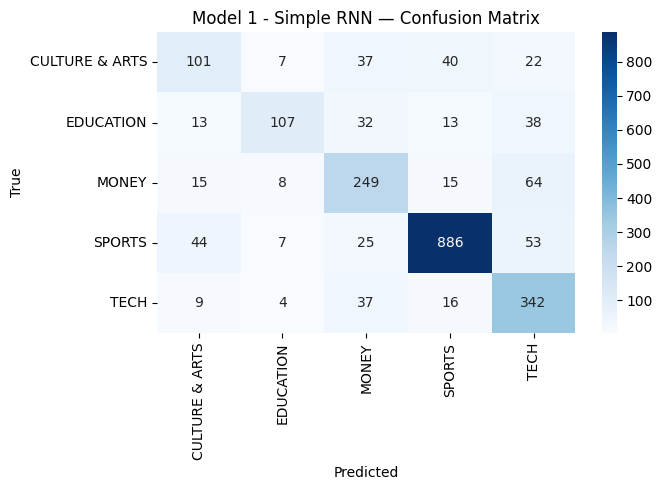


  Model 2 - LSTM
Test Loss     : 0.6199
Test Accuracy : 0.8210

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.62      0.64      0.63       207
     EDUCATION       0.70      0.58      0.64       203
         MONEY       0.74      0.79      0.76       351
        SPORTS       0.93      0.92      0.93      1015
          TECH       0.78      0.82      0.80       408

      accuracy                           0.82      2184
     macro avg       0.75      0.75      0.75      2184
  weighted avg       0.82      0.82      0.82      2184



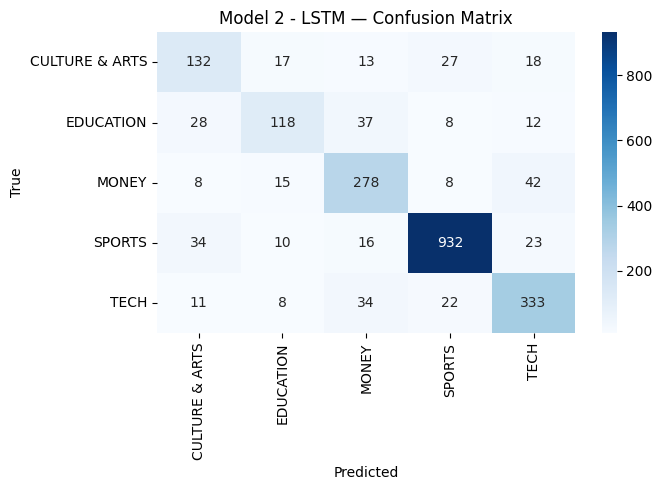


  Model 3 - LSTM GloVe
Test Loss     : 0.4227
Test Accuracy : 0.8654

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.74      0.81      0.78       207
     EDUCATION       0.78      0.74      0.76       203
         MONEY       0.79      0.85      0.82       351
        SPORTS       0.92      0.95      0.94      1015
          TECH       0.91      0.75      0.82       408

      accuracy                           0.87      2184
     macro avg       0.83      0.82      0.82      2184
  weighted avg       0.87      0.87      0.86      2184



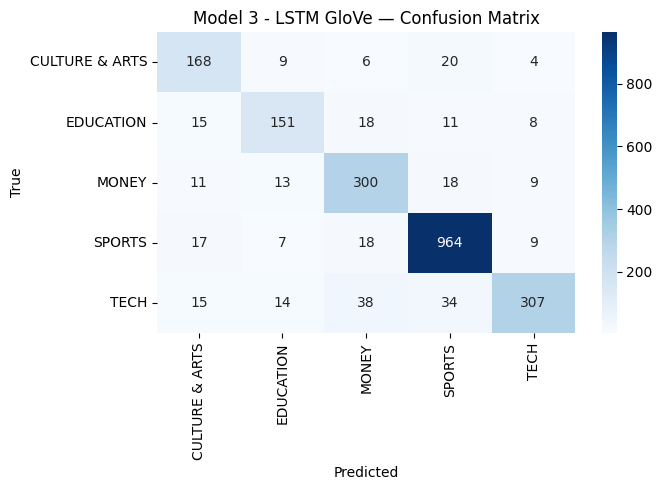

In [52]:
def evaluate_model(model, X_test, y_test_cat, y_test_raw, le, model_name):
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Test Loss     : {loss:.4f}")
    print(f"Test Accuracy : {acc:.4f}\n")

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    print("Classification Report:")
    print(classification_report(y_test_raw, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test_raw, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=100)
    plt.show()
    return y_pred

y_pred1 = evaluate_model(model1, X_test_pad, y_test_cat, y_test, le, 'Model 1 - Simple RNN')
y_pred2 = evaluate_model(model2, X_test_pad, y_test_cat, y_test, le, 'Model 2 - LSTM')
y_pred3 = evaluate_model(model3, X_test_pad, y_test_cat, y_test, le, 'Model 3 - LSTM GloVe')


## 10. Error Analysis

In [53]:
def show_errors(model_name, y_pred, n=3):
    print(f"\n{'='*60}")
    print(f"  {model_name} — Misclassified Examples")
    print(f"{'='*60}")
    errors = np.where(y_pred != y_test)[0]
    print(f"Total misclassified: {len(errors)} / {len(y_test)}")
    for idx in errors[:n]:
        print(f"  Headline : {X_test[idx]}")
        print(f"  True     : {le.classes_[y_test[idx]]}")
        print(f"  Predicted: {le.classes_[y_pred[idx]]}\n")

show_errors('Model 1 — Simple RNN',    y_pred1)
show_errors('Model 2 — LSTM',          y_pred2)
show_errors('Model 3 — LSTM + GloVe', y_pred3)



  Model 1 — Simple RNN — Misclassified Examples
Total misclassified: 499 / 2184
  Headline : secret summer anna
  True     : CULTURE & ARTS
  Predicted: MONEY

  Headline : laura mcphee river return
  True     : CULTURE & ARTS
  Predicted: SPORTS

  Headline : haiku review anime magical realism drag activism photos videos
  True     : CULTURE & ARTS
  Predicted: MONEY


  Model 2 — LSTM — Misclassified Examples
Total misclassified: 391 / 2184
  Headline : secret summer anna
  True     : CULTURE & ARTS
  Predicted: EDUCATION

  Headline : cut politwoops twitter follow need politicians public interest
  True     : TECH
  Predicted: SPORTS

  Headline : tip use video interview hire great teachers
  True     : EDUCATION
  Predicted: MONEY


  Model 3 — LSTM + GloVe — Misclassified Examples
Total misclassified: 294 / 2184
  Headline : dallas police bomb robot raise sticky question
  True     : TECH
  Predicted: SPORTS

  Headline : valuable investment girl education
  True     : EDUCATION


### 10.1 Analysis & Suggested Improvements

**Noise impact discussion:**
- Removing 80 exact duplicate headlines prevents the model from artificially memorising repeated patterns during training.
- The 2 label-conflicting duplicates (`"Learning From the Masters"` labelled as both SPORTS and CULTURE & ARTS) were removed because keeping either copy would introduce a wrong training signal.
- Unicode normalisation ensures curly-quote tokens (e.g. `'s` vs `'s`) are unified, reducing vocabulary fragmentation.
- Collapsing multi-spaces and dropping near-empty headlines avoids padding tokens dominating short sequences.

**Error patterns observed:**
- Short, ambiguous headlines are hardest to classify (minimal context for the model).
- MONEY ↔ TECH cross-confusion is common (e.g. *"Apple's New AI Feature Could Change Finance"*).
- Simple RNN forgets early words in longer headlines; LSTM retains them better.

**Potential improvements:**
1. Bidirectional LSTM to capture both forward and backward context.
2. Fine-tune GloVe embeddings (`trainable=True`) after a warm-up phase.
3. Class-weighted loss to penalise errors on minority categories (EDUCATION, CULTURE & ARTS).
4. Transformer encoder (DistilBERT) for superior contextual representations.
5. Data augmentation via synonym replacement for minority classes.


## 11. Real-Time Prediction — Gradio GUI

In [54]:
!pip install gradio --quiet


In [55]:
import gradio as gr

def predict_headline(headline: str):
    # Step 1: normalise unicode noise (same as Section 3)
    headline = normalise_unicode(headline)
    # Step 2: clean text
    cleaned  = clean_text(headline)
    # Step 3: tokenise + pad
    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    p1 = model1.predict(padded, verbose=0)[0]
    p2 = model2.predict(padded, verbose=0)[0]
    p3 = model3.predict(padded, verbose=0)[0]
    avg = (p1 + p2 + p3) / 3

    confidences = {le.classes_[i]: float(avg[i]) for i in range(NUM_CLASSES)}
    individual  = (
        f"**Model 1 (RNN):** {le.classes_[np.argmax(p1)]}  \n"
        f"**Model 2 (LSTM):** {le.classes_[np.argmax(p2)]}  \n"
        f"**Model 3 (LSTM+GloVe):** {le.classes_[np.argmax(p3)]}  \n"
        f"**Ensemble:** {le.classes_[np.argmax(avg)]}"
    )
    return individual, confidences

demo = gr.Interface(
    fn=predict_headline,
    inputs=gr.Textbox(lines=2, placeholder="Enter a news headline…", label="Headline"),
    outputs=[
        gr.Markdown(label="Per-Model Predictions"),
        gr.Label(num_top_classes=5, label="Ensemble Confidence"),
    ],
    title="News Category Predictor",
    description="Type a headline and see predictions from all three models.",
    examples=[
        ["Apple unveils new MacBook Pro with M4 chip"],
        ["Champions League final ends in dramatic penalty shootout"],
        ["Fed holds rates steady amid inflation fears"],
        ["New study reveals impact of social media on student grades"],
    ],
    theme=gr.themes.Soft(),
)

demo.launch(share=True)


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://bcb114387a35953be1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
